This notebook demonstrates the capabilities of the raytracer in computing attenuation and phase shifts, and uses this to create synthetic diffraction patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../../')     # import path/to/synthpy

import src.simulator.config as config
config.jax_init(enable_x64 = True)

import simulator.beam as beam_initialiser
import simulator.domain as d
import simulator.propagator as p
import processing.diagnostics as diag
import processing.plotting as plots

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

Setting top level path for imports: C:\Users\qinal\OneDrive - Imperial College London\UROP\synthPy\src

Disabling python multi-threading...
Initialising jax...


Default jax backend: cpu
Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19)]


<module 'processing.diagnostics' from 'C:\\Users\\qinal\\OneDrive - Imperial College London\\UROP\\synthPy\\src\\processing\\diagnostics.py'>

In [2]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3

n_cells = 128

#x = np.linspace(-extent_x, extent_x, n_cells)
#y = np.linspace(-extent_y, extent_y, n_cells)
#z = np.linspace(-extent_z, extent_z, n_cells)

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])
rho1 = np.full((n_cells, n_cells, n_cells), 1e3)
Te = np.full((n_cells, n_cells, n_cells), 2e3)
Z = np.float32(np.linspace(-extent_z/2, extent_z/2, n_cells))
#domain = d.ScalarDomain(x = x, y = y, z = z, extent = probing_extent, probing_direction = probing_direction)     # create domain
# Much simpler domain function, no longer needlessly takes in beam values, they are fully seperated
domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, 
                        opacity = True, num_materials=1, densities = rho1, Te = Te, 
                        opacity_files="opa_CH_NLTE_Full_linear1000.spk", phaseshift=True, ne_0 = 1e29, Ly = extent_y*0.5) # B_on = False by default
#domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction, inv_brems=True, Te = Te, Z = Z) # B_on = False by default

# load some external pvti
# import utils.handle_filetypes as load
# ne, dim, spacing = load.pvti_readin(filename)
# or load a test distribution

# only necessary to do so if you are not using the domain initialisation default distribution loading
# - that is the best option if using a test distribution

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 15.616397857666016 GB
 - free  : 2.4541664123535156 GB
 - used  : 13.1622314453125 GB

Est. domain memory limit: 48.0 MB
 --> inc. +100.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


In [3]:
lwl = 0.1e-9 #define laser wavelength

# initialise beam
Np = 100000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = 0.9*extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'square'

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = beam_type
)

# domain.dim - this causes a TracerBoolConversionError
# passing r_n all individually works though
# also passing ScalarDomain and extracting dim in p.solve(...) causes the same issue
# issue is due to unkown value when assigned to diffrax

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent)
# defaults: return_E = False, parallelise = True, jitted = True, save_points_per_region = 2, memory_debug = False, lwl = 1064e-9, keep_domain = False, return_raw_results = False


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 840 B): 80.108642578125 MB
 --> Np = 100000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: cpu, with: 20 cores.
NamedSharding(mesh=Mesh('rows': 20, axis_types=(Auto,)), spec=PartitionSpec('rows', None), memory_kind=unpinned_host)

jax compilation of solver took: 0.001026153564453125 secondshi
hi
hi

Completed ray trace in 23.025 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 9]: (100000, 2, 9)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 9 containing the 3 position and velocity components, amplitude, phase and polarisation
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results

0.0


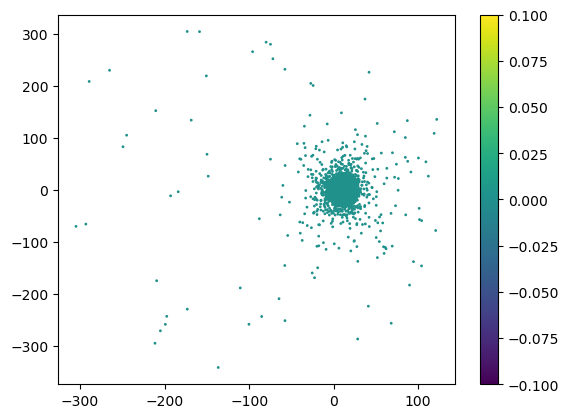

In [4]:

plt.scatter(rf[0, :], rf[2, :], c=rf[5, :],s=1)
plt.colorbar()
print(rf[5, :].min())


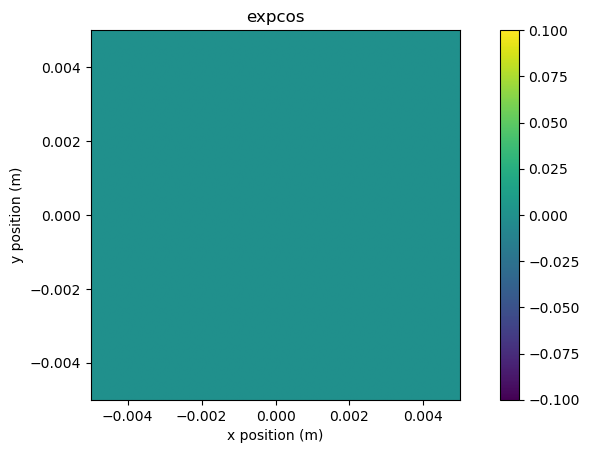

In [6]:
plots.propagated_field(domain, rf[0], rf[2], 5, rf[5], rf[4], 400, 400, "expcos", 0.1e-9)